In [1]:
import os
import time
import pickle
import numpy as np
import networkx as nx

from GNN import GNN
from tree import Node, Tree
from homomorphism import total_hom, total_hom_preprocess, refine_colours

In [2]:
def fb_test():
    with open("edges.pkl", "rb") as f:
        edges = pickle.load(f)
    
    G = GNN(edges=edges, directed=False)

    return G

In [3]:
trees = list(nx.generators.nonisomorphic_trees(7))

In [4]:
G = fb_test()

arr = []

for i in range(len(trees)):
    print(f"Computing Tree {i}")
    T = Tree(edges=trees[i].edges)
    T = T.nodes[1]
    arr.append(total_hom(T, G))

print(arr)

Computing Tree 0
Computing Tree 1
Computing Tree 2
Computing Tree 3
Computing Tree 4
Computing Tree 5
Computing Tree 6
Computing Tree 7
Computing Tree 8
Computing Tree 9
Computing Tree 10
[263551452824, 342345027598, 337069505659, 512594785666, 447839597232, 428106772994, 637742679544, 332336119774, 491856871650, 820089087172, 1472937130072]


In [15]:
deltas = {i: [] for i in range(len(trees))}
A, colour_count = refine_colours(G)

tree = Tree(edges=list(trees[2].edges))

tree = tree.nodes[1]

total_hom_preprocess(tree, G, colour_count, A)

337069505659

In [16]:
for i in range(10):
    print(f"Processing Iteration #{i + 1}...")
    for index, tree in enumerate(trees):
        delta = time.time()
        tree = Tree(edges=list(trees[i].edges))
        tree = tree.nodes[1]
        total_hom_preprocess(tree, G, colour_count, A)
        delta = time.time() - delta
        deltas[index].append(delta)
    print(f"Completed Iteration #{i + 1}!")

Processing Iteration #1...
Completed Iteration #1!
Processing Iteration #2...
Completed Iteration #2!
Processing Iteration #3...
Completed Iteration #3!
Processing Iteration #4...
Completed Iteration #4!
Processing Iteration #5...
Completed Iteration #5!
Processing Iteration #6...
Completed Iteration #6!
Processing Iteration #7...
Completed Iteration #7!
Processing Iteration #8...
Completed Iteration #8!
Processing Iteration #9...
Completed Iteration #9!
Processing Iteration #10...
Completed Iteration #10!


In [18]:
new_deltas = deltas.copy()
for i in range(len(new_deltas)):
    new_deltas[i] = np.array(new_deltas[i]).mean()

In [19]:
new_deltas

{0: np.float64(3.362086224555969),
 1: np.float64(3.3785966634750366),
 2: np.float64(3.399767255783081),
 3: np.float64(3.4054059028625487),
 4: np.float64(3.3923823833465576),
 5: np.float64(3.4162857055664064),
 6: np.float64(3.454900312423706),
 7: np.float64(3.387289595603943),
 8: np.float64(3.416793179512024),
 9: np.float64(3.3867736577987673),
 10: np.float64(3.3558828115463255)}

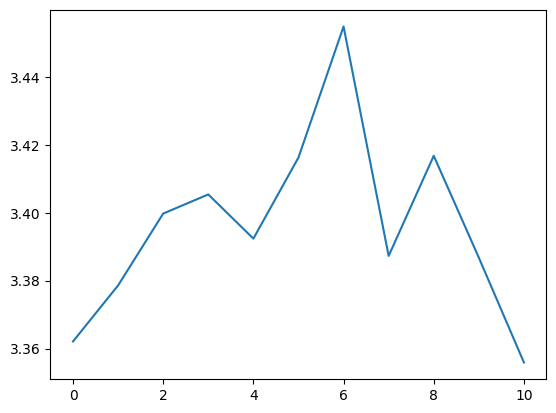

In [28]:
import matplotlib.pyplot as plt

x = list(new_deltas.keys())
y = list(new_deltas.values())

plt.plot(x, y)